Importing Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Reading Dataset

In [6]:
df=pd.read_csv("semiconductor_stocks_data_2015_2025.csv")
df.head()

,company_name,stock_name,date,open,high,low,close,volume
0,Analog Devices,ADI,2015-01-02,44.799830,45.258449,44.228568,44.687187,1323200
1,Analog Devices,ADI,2015-01-05,44.574549,44.614779,43.850413,43.874550,1445200
2,Analog Devices,ADI,2015-01-06,44.035461,44.091783,42.812477,42.844662,1707500
3,Analog Devices,ADI,2015-01-07,43.037761,43.552701,42.667645,43.295231,1723000
4,Analog Devices,ADI,2015-01-08,43.761902,44.397532,43.512479,44.059601,1874900


In [7]:
df.tail()

,company_name,stock_name,date,open,high,low,close,volume
50584,Texas Instruments,TXN,2025-07-28,186.531773,189.172674,186.402701,187.891937,8586800
50585,Texas Instruments,TXN,2025-07-29,188.348639,191.505812,187.544439,190.006653,7144700
50586,Texas Instruments,TXN,2025-07-30,190.771120,191.198043,186.948757,188.160004,6985100
50587,Texas Instruments,TXN,2025-07-31,186.139999,186.910004,179.809998,181.059998,10144000
50588,Texas Instruments,TXN,2025-08-01,179.630005,181.589996,177.919998,180.860001,6623900


Data Sanity Check

In [8]:
df.shape 

(50589, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50589 entries, 0 to 50588
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  50589 non-null  object 
 1   stock_name    50589 non-null  object 
 2   date          50589 non-null  object 
 3   open          50589 non-null  float64
 4   high          50589 non-null  float64
 5   low           50589 non-null  float64
 6   close         50589 non-null  float64
 7   volume        50589 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 3.1+ MB


In [10]:
#Looking for missing values
df.isnull().sum()

company_name    0
stock_name      0
date            0
open            0
high            0
low             0
close           0
volume          0
dtype: int64

In [11]:
#Looking for duplicates
df.duplicated().sum()


np.int64(0)

In [49]:
#Looking for garbage values
for i in df.select_dtypes (include="object").columns:
 print(df[i].value_counts())
 print("***"*10)
 

company_name
Infineon                2691
Analog Devices          2661
Marvell Technology      2661
TSMC                    2661
STMicroelectronics      2661
QUALCOMM                2661
ON Semiconductor        2661
NXP Semiconductors      2661
NVIDIA                  2661
Micron Technology       2661
Microchip Technology    2661
Applied Materials       2661
Lam Research            2661
KLA                     2661
Intel                   2661
Broadcom                2661
ASML                    2661
AMD                     2661
Texas Instruments       2661
Name: count, dtype: int64
******************************
stock_name
IFX.DE    2691
ADI       2661
MRVL      2661
TSM       2661
STM       2661
QCOM      2661
ON        2661
NXPI      2661
NVDA      2661
MU        2661
MCHP      2661
AMAT      2661
LRCX      2661
KLAC      2661
INTC      2661
AVGO      2661
ASML      2661
AMD       2661
TXN       2661
Name: count, dtype: int64
******************************
date
2015-01-02    19
2022

Exploratory Data Analysis (EDA)

In [48]:
#descriptive statistics 
df.describe()

,open,high,low,close,volume
count,50589.000000,50589.000000,50589.000000,50589.000000,5.058900e+04
mean,90.721203,91.941479,89.450244,90.724579,3.665891e+07
std,129.335066,130.975824,127.583072,129.331154,1.160146e+08
min,0.463628,0.467947,0.454509,0.459308,0.000000e+00
25%,23.656285,23.981890,23.309616,23.647720,3.360200e+06
50%,49.976784,50.589230,49.314851,49.939941,7.211300e+06
75%,102.320894,103.709999,101.034279,102.352776,1.873920e+07
max,1096.841562,1096.950245,1063.095736,1085.942017,3.692928e+09


In [18]:
df.describe(include='object')

,company_name,stock_name,date
count,50589,50589,50589
unique,19,19,2733
top,Infineon,IFX.DE,2015-01-02
freq,2691,2691,19


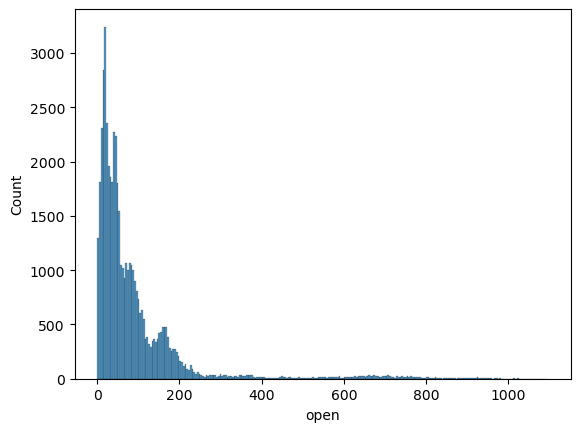

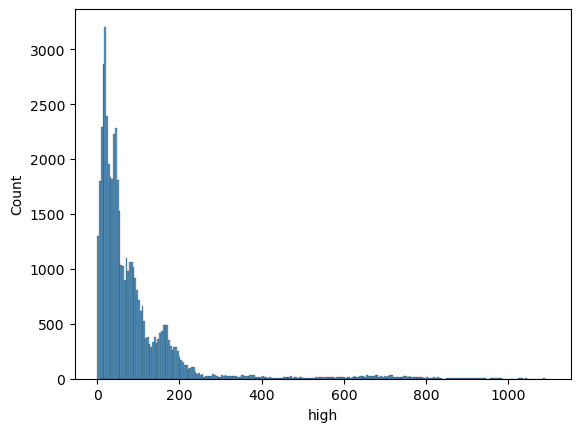

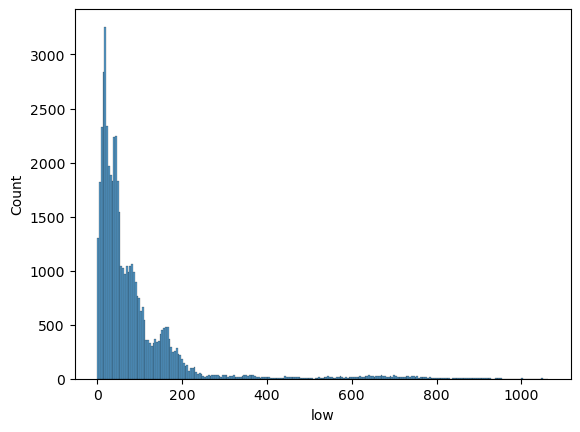

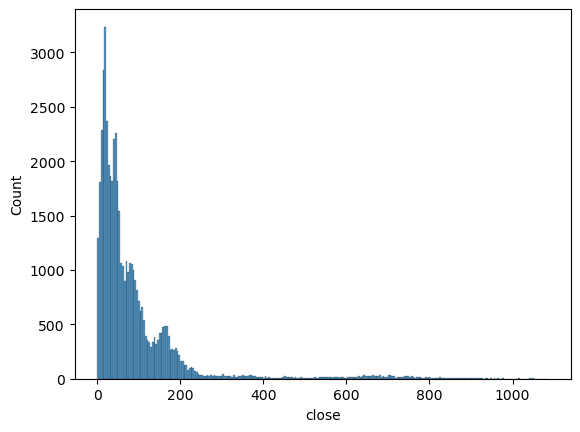

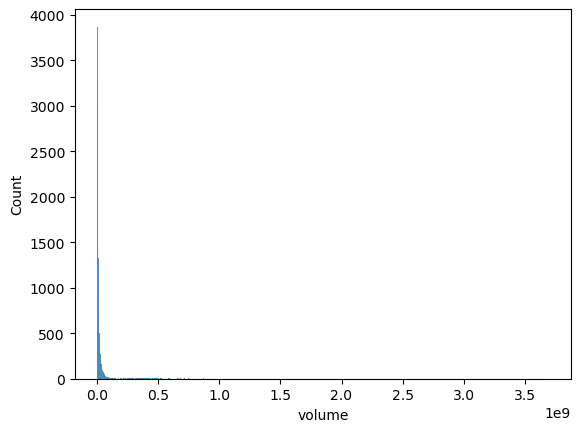

In [20]:
#Distribution Histogram
for i in df.select_dtypes (include="number").columns:
 sns.histplot(data=df,x=i)
 plt.show()

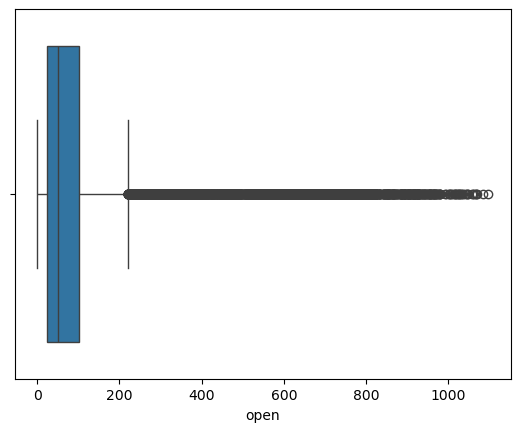

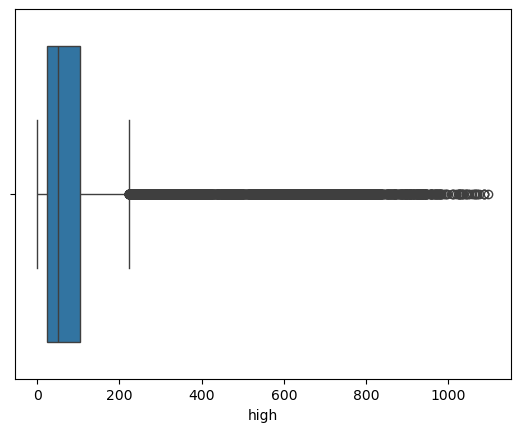

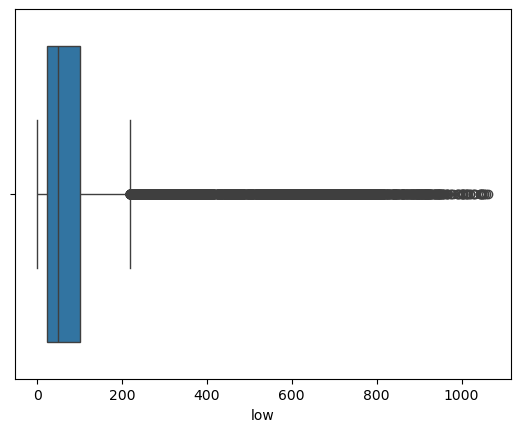

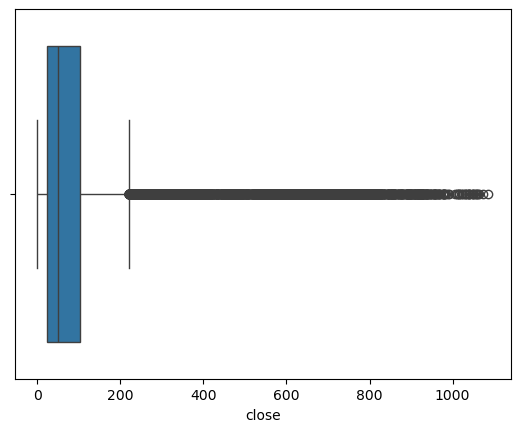

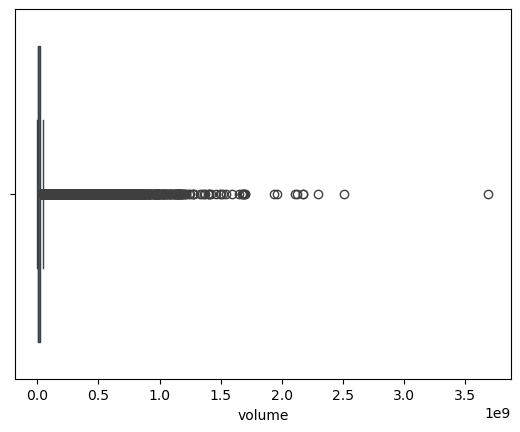

In [22]:
#Identifying outliers using boxplot
for i in df.select_dtypes (include="number").columns:
 sns.boxplot(data=df,x=i)
 plt.show()

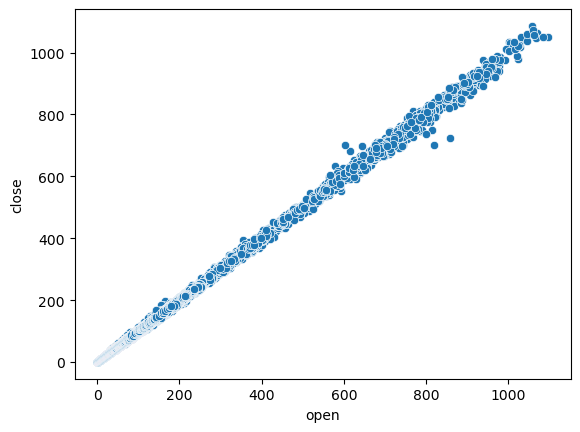

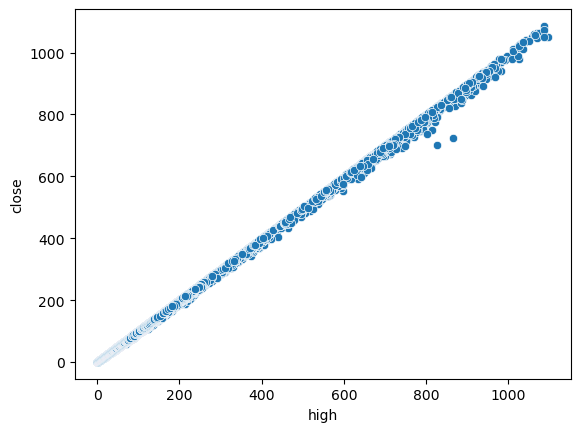

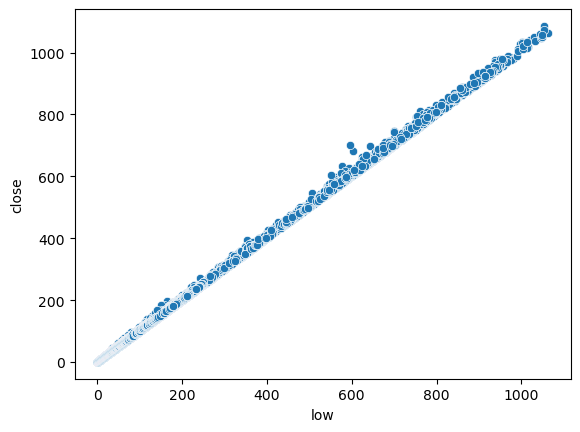

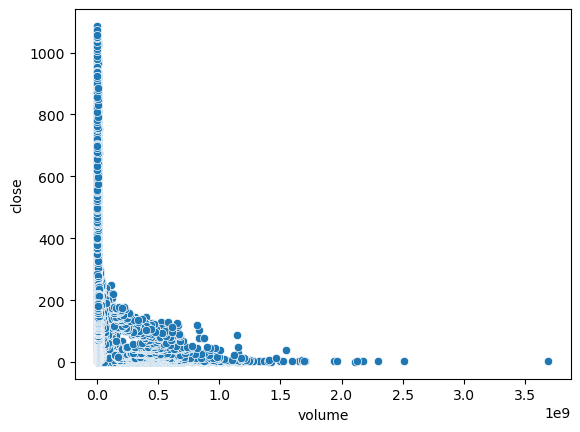

In [27]:
#Relationship of close value with others (Scatter Plot)
for i in ['open', 'high', 'low', 'volume']:
    sns.scatterplot(data=df, x=i, y='close')
    plt.show()

In [43]:
#Correlation
df.select_dtypes(include="number").corr()

,open,high,low,close,volume
open,1.000000,0.999885,0.999857,0.999715,-0.137878
high,0.999885,1.000000,0.999830,0.999861,-0.137521
low,0.999857,0.999830,1.000000,0.999889,-0.138345
close,0.999715,0.999861,0.999889,1.000000,-0.137915
volume,-0.137878,-0.137521,-0.138345,-0.137915,1.000000


<Axes: >

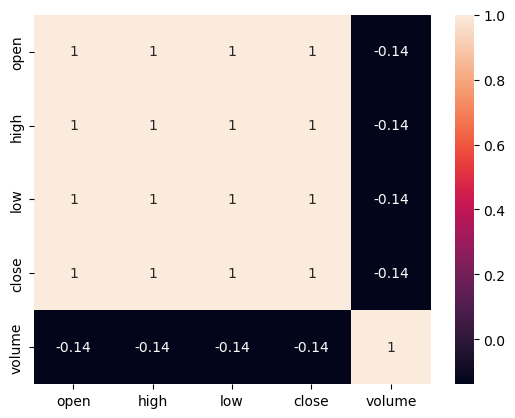

In [42]:
#Correlation Heatmap
storedata=df.select_dtypes (include="number").corr()
sns.heatmap(storedata, annot=True)

In [ ]:
#Missing Value Treatment
#Check for missing values
df.isnull().sum()

company_name    0
stock_name      0
date            0
open            0
high            0
low             0
close           0
volume          0
dtype: int64